### [1]: Chargement du Dataset

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement du dataset Fashion MNIST
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Noms des 10 catégories exactes de Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



In [ ]:
# 2. Affichage d'un échantillon pour visualiser les classes
plt.figure(figsize=(10, 10))
for i in range(25):
    # Création d'une grille de 5x5 images
    plt.subplot(5, 5, i + 1)
    plt.xticks([]) # On cache les graduations de l'axe X
    plt.yticks([]) # On cache les graduations de l'axe Y
    plt.grid(False)
    
    # Affichage de l'image en niveaux de gris
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    
    # Ajout du nom du vêtement en dessous de chaque image
    plt.xlabel(class_names[y_train[i]])

plt.tight_layout()
plt.show()

### [2]: Prétraitement des données

In [ ]:
# 1. Normalisation (Transformation des pixels de 0-255 vers 0-1)
# On convertit en nombres décimaux (float32) pour éviter les erreurs d'arrondi
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("--- AVANT APLATISSEMENT ---")
print("Forme des images d'entraînement :", x_train_norm.shape) 
# Va afficher (60000, 28, 28)

# 2. Adaptation de la forme (Aplatir les images pour les couches Dense)
# On transforme la grille 2D (28x28) en un vecteur 1D (784)
x_train_flat = x_train_norm.reshape(-1, 28 * 28)
x_test_flat = x_test_norm.reshape(-1, 28 * 28)

print("\n--- APRÈS APLATISSEMENT ---")
print("Nouvelle forme prête pour le modèle :", x_train_flat.shape)
# Va afficher (60000, 784)

### [3]:  Entraînement du modèle

In [24]:
# 3. Construction du modèle MLP
model_fashion = keras.Sequential([
    # La couche cachée : 128 neurones qui reçoivent nos 784 pixels
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    
    # La couche de sortie : 10 neurones (nos 10 ampoules pour les 10 types de vêtements)
    keras.layers.Dense(10, activation='softmax')
])

# 4. Compilation du modèle
model_fashion.compile(
    optimizer='adam',
    # "sparse" indique à Keras de faire le One-Hot Encoding tout seul en arrière-plan !
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# 5. Entraînement du modèle
print("Lancement de l'entraînement...")
# On utilise validation_split=0.2 pour garder 20% des données d'entraînement 
# afin de vérifier en direct que le modèle ne triche pas (Overfitting)
history = model_fashion.fit(
    x_train_flat, 
    y_train, 
    epochs=10, 
    validation_split=0.2 
)

# 6. Évaluation finale sur les données de test (l'examen final)
print("\n Résultats de l'évaluation sur les images de test (jamais vues) :")
test_loss, test_acc = model_fashion.evaluate(x_test_flat, y_test, verbose=2)

print(f"-> Précision finale (Accuracy) : {test_acc * 100:.2f}%")

Lancement de l'entraînement...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8171 - loss: 0.5227 - val_accuracy: 0.8473 - val_loss: 0.4269
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8585 - loss: 0.3949 - val_accuracy: 0.8675 - val_loss: 0.3740
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8731 - loss: 0.3515 - val_accuracy: 0.8698 - val_loss: 0.3580
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8807 - loss: 0.3241 - val_accuracy: 0.8769 - val_loss: 0.3494
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8870 - loss: 0.3060 - val_accuracy: 0.8723 - val_loss: 0.3490
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8933 - loss: 0.2853 - val_accuracy: 0.8809 - val_loss: 0.3328
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8991 - loss: 0.2732 - val_accuracy: 0.8842 - val_loss: 0.3236
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step -

### [4]: Visualisation des performances

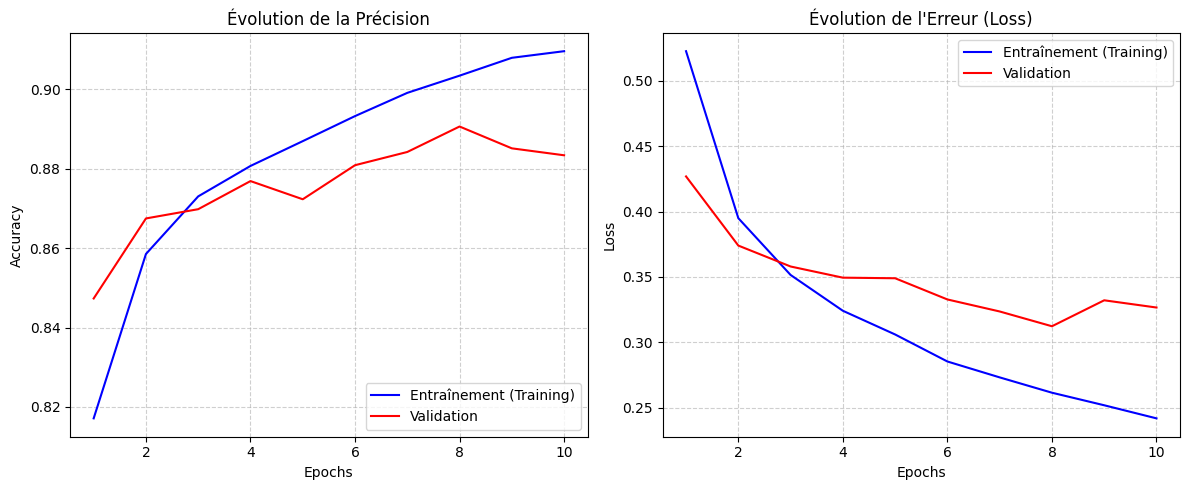

In [25]:
# 1. Extraction des données de l'historique
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Création d'une liste pour l'axe des X (de 1 au nombre total d'epochs)
epochs_range = range(1, len(acc) + 1)

# 2. Création de la figure (largeur 12, hauteur 5)
plt.figure(figsize=(12, 5))

# --- Graphique 1 : La Précision (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-', label='Entraînement (Training)')
plt.plot(epochs_range, val_acc, 'r-', label='Validation')
plt.title('Évolution de la Précision')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Graphique 2 : L'Erreur (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-', label='Entraînement (Training)')
plt.plot(epochs_range, val_loss, 'r-', label='Validation')
plt.title('Évolution de l\'Erreur (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Affichage propre
plt.tight_layout()
plt.show()

### [5]:  Prédiction sur de nouvelles images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


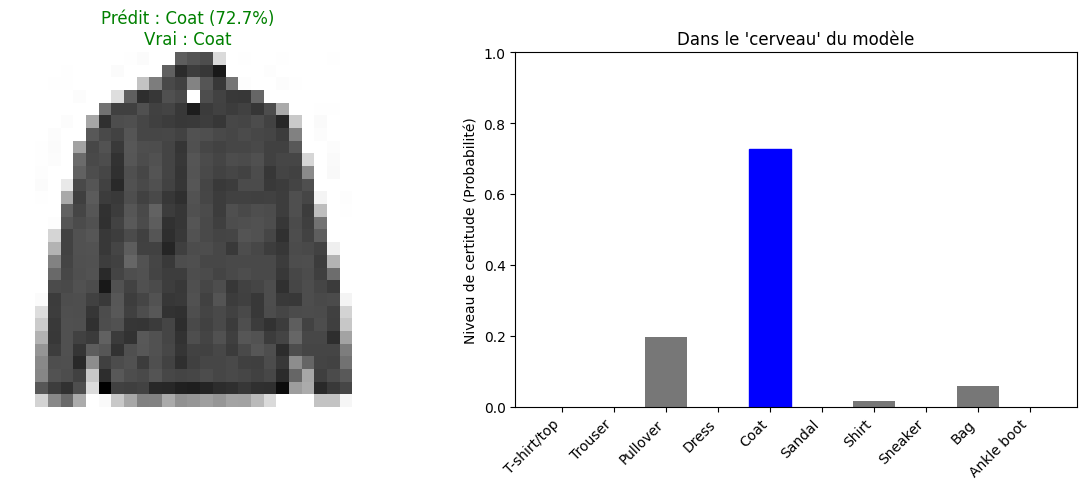

In [47]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Sélectionner une image au hasard
index = random.randint(0, len(x_test) - 1)
image_2d = x_test[index]
image_flat = x_test_flat[index]
vrai_label = y_test[index]

# 2. La prédiction complète
# [0] à la fin permet de sortir les 10 probabilités de la liste globale du batch
predictions_array = model_fashion.predict(np.array([image_flat]))[0] 
index_predit = np.argmax(predictions_array)

# 3. Création de la figure (plus large pour mettre deux graphiques côte à côte)
plt.figure(figsize=(12, 5))

# --- PARTIE GAUCHE : L'image ---
plt.subplot(1, 2, 1)
plt.imshow(image_2d, cmap=plt.cm.binary)

# On gère les couleurs et les textes
couleur = 'green' if index_predit == vrai_label else 'red'
nom_predit = class_names[index_predit]
nom_vrai = class_names[vrai_label]

plt.title(f"Prédit : {nom_predit} ({100*np.max(predictions_array):.1f}%)\nVrai : {nom_vrai}", color=couleur)
plt.axis('off')

# --- PARTIE DROITE : Le graphique des 10 ampoules (Probabilités) ---
plt.subplot(1, 2, 2)
# On crée les barres grises
bar_plot = plt.bar(range(10), predictions_array, color="#777777")
plt.xticks(range(10), class_names, rotation=45, ha='right')
plt.ylim([0, 1]) # L'axe Y va de 0 à 1 (soit 0% à 100%)
plt.ylabel("Niveau de certitude (Probabilité)")
plt.title("Dans le 'cerveau' du modèle")

# La magie des couleurs sur le graphique :
# La barre de la bonne réponse est colorée en BLEU
bar_plot[vrai_label].set_color('blue')
# Si le modèle s'est trompé, sa fausse prédiction est colorée en ROUGE
if index_predit != vrai_label:
    bar_plot[index_predit].set_color('red')

plt.tight_layout()
plt.show()